In [1]:
import pyvista as pv
import numpy as np

stl  = pv.read("constant/triSurface/monobob.stl")
mesh = pv.read("VTK/01_mono_0/boundary/monobob.vtp")

result = mesh.compute_implicit_distance(stl)
d = np.abs(result["implicit_distance"])

print(f"Mean error : {d.mean()*1000:.3f} mm")
print(f"RMS error  : {np.sqrt(np.mean(d**2))*1000:.3f} mm")
print(f"Max error  : {d.max()*1000:.3f} mm")

Mean error : 0.037 mm
RMS error  : 0.247 mm
Max error  : 4.999 mm


/users/eleves-a/2023/thanh.diep/venvs/cfd/lib64/python3.9/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/users/eleves-a/2023/thanh.diep/venvs/cfd/lib64/python3.9/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


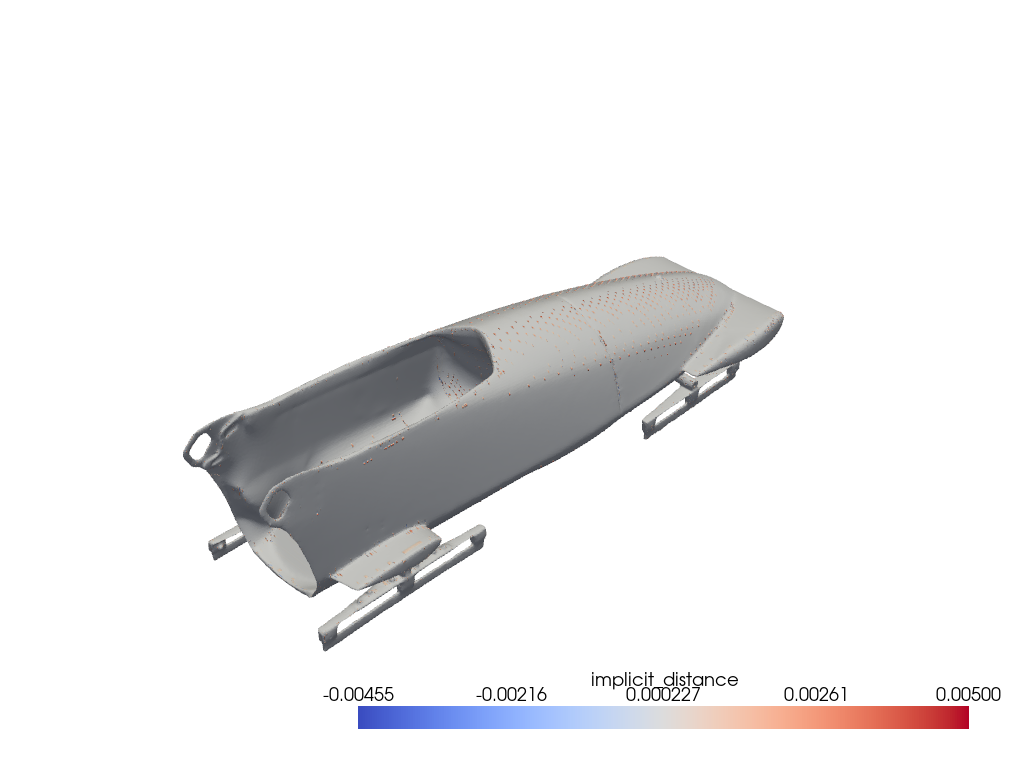

In [2]:
result.save("distance_map.vtk")

p = pv.Plotter()
p.add_mesh(result, scalars="implicit_distance", cmap="coolwarm")
p.show()

/users/eleves-a/2023/thanh.diep/venvs/cfd/lib64/python3.9/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/users/eleves-a/2023/thanh.diep/venvs/cfd/lib64/python3.9/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


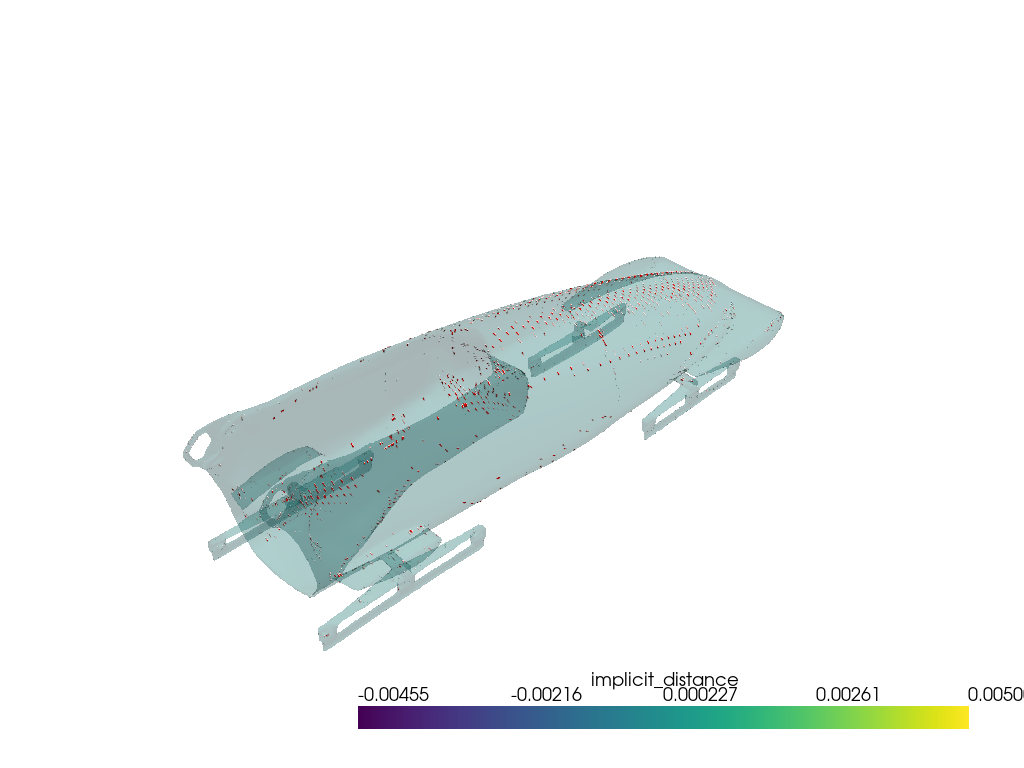

In [3]:
threshold = 0.002
bad = result.threshold(value=threshold, scalars="implicit_distance")
p = pv.Plotter()

p.add_mesh(result, scalars="implicit_distance", opacity=0.2)
p.add_mesh(bad, color="red")
p.show()

In [4]:
pts = bad.points

xmin, ymin, zmin = pts.min(axis=0)
xmax, ymax, zmax = pts.max(axis=0)

print(xmin, ymin, zmin)
print(xmax, ymax, zmax)

print(bad.n_points)

-1.4204416 -0.4225676 0.003125
1.3829145 0.42227587 0.73125
22223


In [5]:
# localize the 26 mm deviation

imax = np.argmax(d)
pmax = mesh.points[imax]

print(d[imax])
print(pmax)

0.004999440411988421
[-0.98125    0.2734375  0.29375  ]


/users/eleves-a/2023/thanh.diep/venvs/cfd/lib64/python3.9/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/users/eleves-a/2023/thanh.diep/venvs/cfd/lib64/python3.9/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


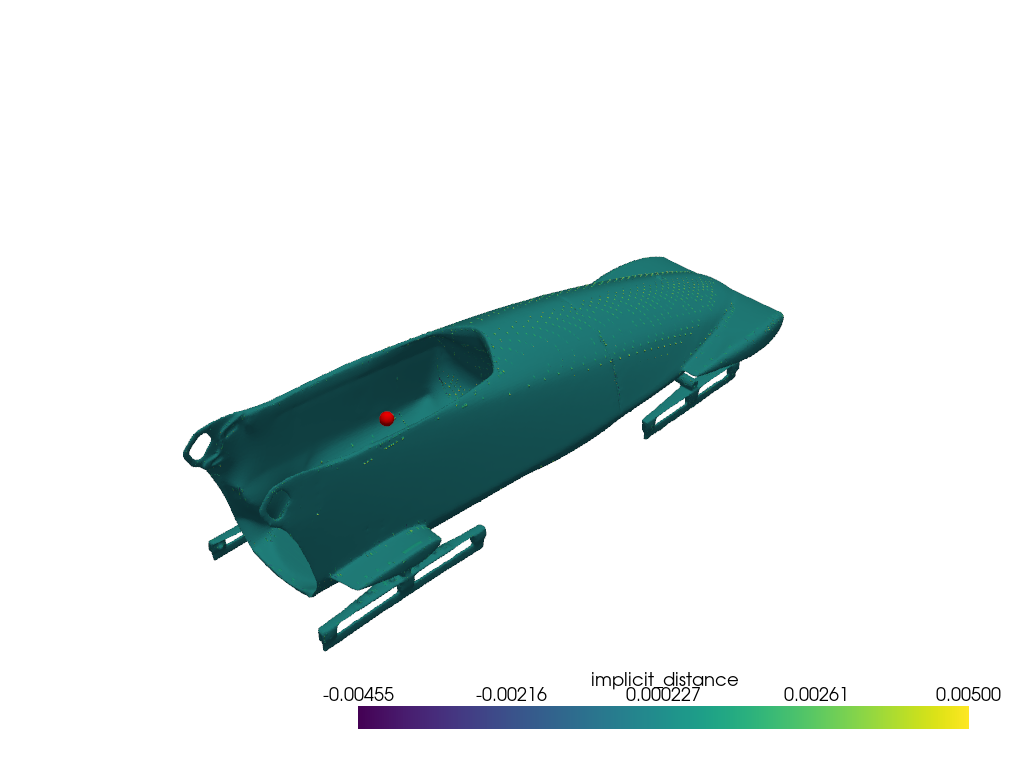

In [6]:
# visualize troublemaker spot
import pyvista as pv

sphere = pv.Sphere(radius=0.03, center=[0.48291054, -0.19614866, 0.35072783])

p = pv.Plotter()

p.add_mesh(result, scalars="implicit_distance")
p.add_mesh(sphere, color="red")

p.show()

In [7]:
import pyvista as pv
import numpy as np

SKEW_LIMIT = 4.0
surf = pv.read("VTK/01_mono_0/boundary/monobob.vtp")
wall_skew = surf["skewness"]
total_area = surf.area

bad = surf.threshold(value=SKEW_LIMIT, scalars="skewness")
bad_area = bad.area

ratio = 100.0 * bad_area / total_area

print("\n===================================")
print(" MONOBOB WALL SKEWNESS ANALYSIS")
print("===================================")

print(f"Total surface area : {total_area:.6f} m²")
print(f"Bad surface area   : {bad_area:.6f} m²")
print(f"Area ratio         : {ratio:.4f} %")

print(f"\nThreshold skewness : {SKEW_LIMIT}")

print(f"\nMax wall skewness  : {wall_skew.max():.4f}")
print(f"Mean wall skewness : {wall_skew.mean():.4f}")
print(f"Median skewness    : {np.median(wall_skew):.4f}")

surf.save("monobob_surface_with_skewness.vtp")
bad.save("bad_skew_regions.vtu")


 MONOBOB WALL SKEWNESS ANALYSIS
Total surface area : 7.516609 m²
Bad surface area   : 0.000240 m²
Area ratio         : 0.0032 %

Threshold skewness : 4.0

Max wall skewness  : 9.1684
Mean wall skewness : 0.2767
Median skewness    : 0.1692


/users/eleves-a/2023/thanh.diep/venvs/cfd/lib64/python3.9/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/users/eleves-a/2023/thanh.diep/venvs/cfd/lib64/python3.9/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


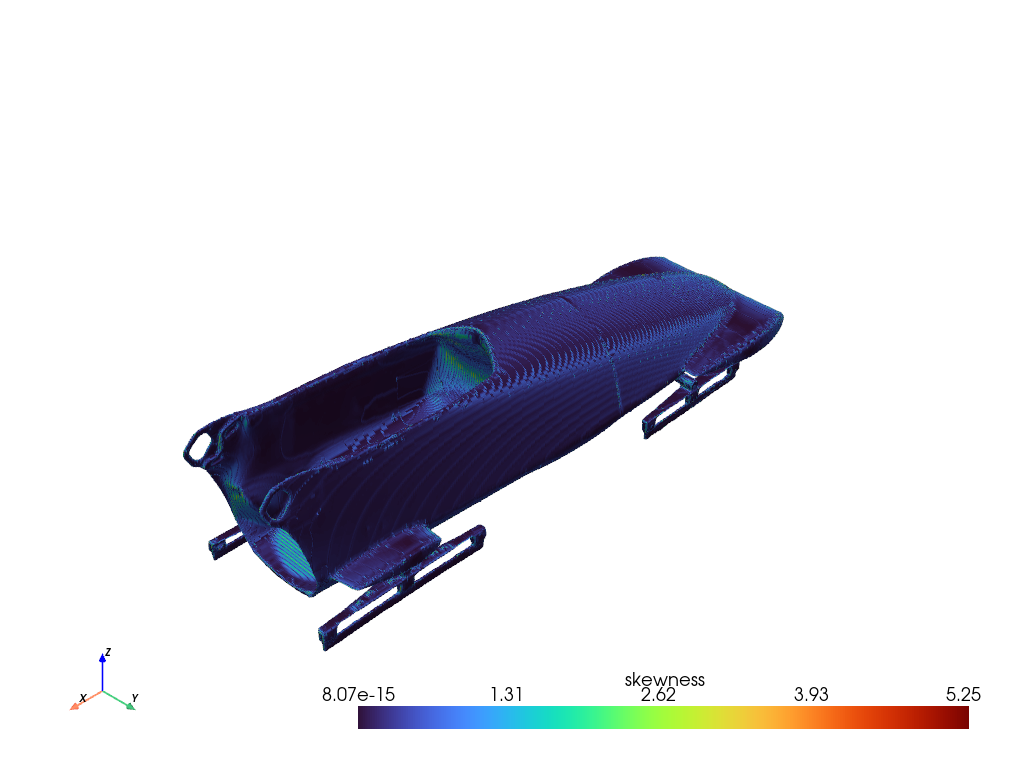

/users/eleves-a/2023/thanh.diep/venvs/cfd/lib64/python3.9/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/users/eleves-a/2023/thanh.diep/venvs/cfd/lib64/python3.9/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


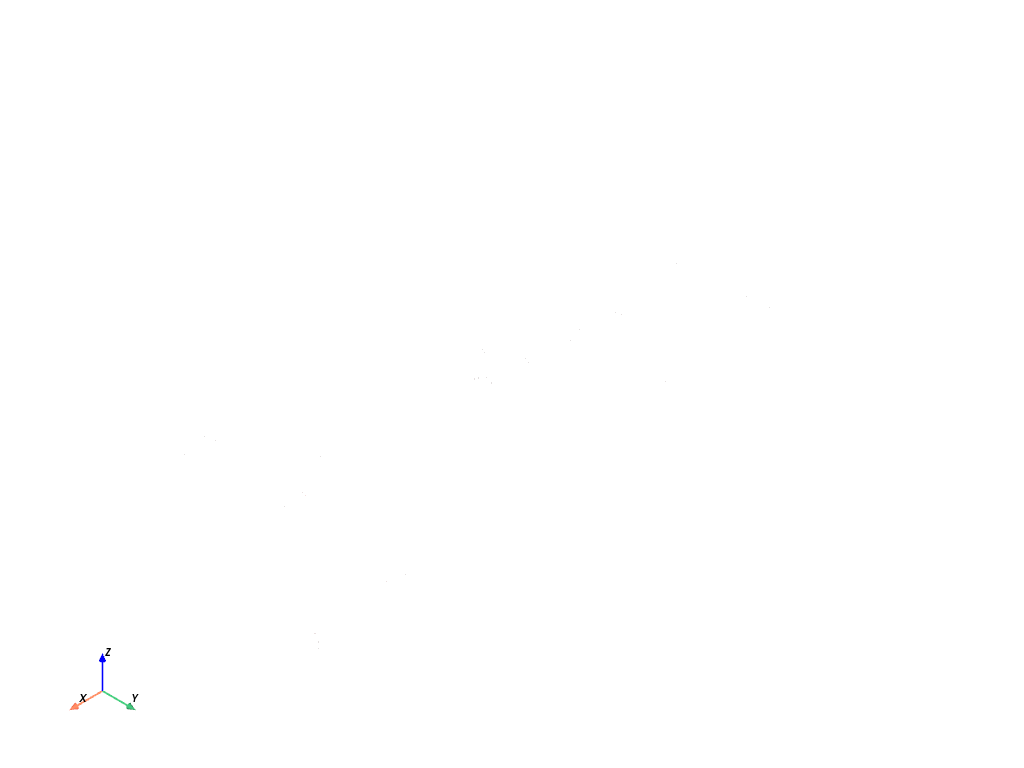

In [8]:
surf.plot(scalars="skewness", cmap="turbo", show_edges=False)
bad.plot(color="red")

In [11]:
mesh = pv.read("distance_map.vtk")

thr = 0.002

areas = mesh.compute_cell_sizes()["Area"]

d = np.abs(mesh["implicit_distance"])

cell_d = []

for cell in range(mesh.n_cells):
    ids = mesh.get_cell(cell).point_ids
    cell_d.append(np.max(d[ids]))

cell_d = np.array(cell_d)

bad = cell_d > thr

A_total = np.sum(areas)
A_bad   = np.sum(areas[bad])

print("===================================")
print(" GEOMETRY DEVIATION AREA ANALYSIS")
print("===================================")

print(f"Total area      : {A_total:.6f} m²")
print(f"Bad area        : {A_bad:.6f} m²")
print(f"Area ratio      : {100*A_bad/A_total:.4f} %")
print()
print(f"Threshold        : {thr*1000:.1f} mm")
print(f"Bad cells        : {np.sum(bad)}")

 GEOMETRY DEVIATION AREA ANALYSIS
Total area      : 7.516609 m²
Bad area        : 0.119658 m²
Area ratio      : 1.5919 %

Threshold        : 2.0 mm
Bad cells        : 10690
